<a href="https://colab.research.google.com/github/samuel127jules/es22452/blob/main/Lab11ES2245.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.cluster import KMeans
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense

print("Libraries imported successfully. Environment is ready!")

Libraries imported successfully. Environment is ready!


Calculated Uplift Rate: 4.23 mm/yr


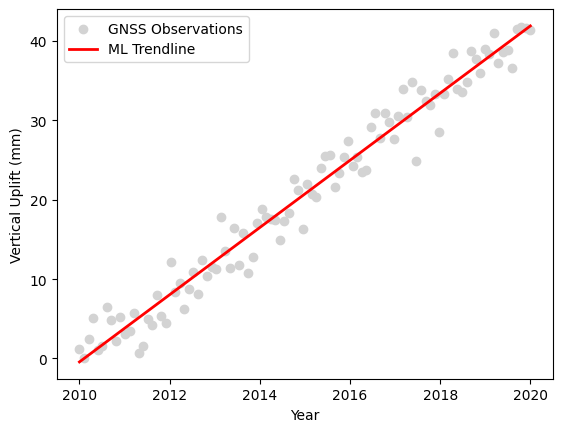

In [2]:
# Synthetic Data: Time (years) vs. Vertical Displacement (mm)
np.random.seed(42)
years = np.linspace(2010, 2020, 100).reshape(-1, 1)

vertical_displacement = 4.2 * (years - 2010) + np.random.normal(0, 2.5, 100).reshape(-1, 1)

model = LinearRegression()

model.fit(years, vertical_displacement)

uplift_rate = model.coef_[0][0]

print(f"Calculated Uplift Rate: {uplift_rate:.2f} mm/yr")

plt.scatter(years, vertical_displacement, label="GNSS Observations", color='lightgray')
plt.plot(years, model.predict(years), color='red', linewidth=2, label="ML Trendline")
plt.xlabel("Year")
plt.ylabel("Vertical Uplift (mm)")
plt.legend()
plt.show()

**If the calculated slope is positive, what is happening to the ground level physically?**

The ground is rising over time, maybe nire tectonic uplift.

**Why use Machine Learning (Regression) instead of just drawing a line from the first data point to the last?**

The machine learning uses all of the points to minimize the amount of error in the drawn line, this inadvertently reduces noise as well.


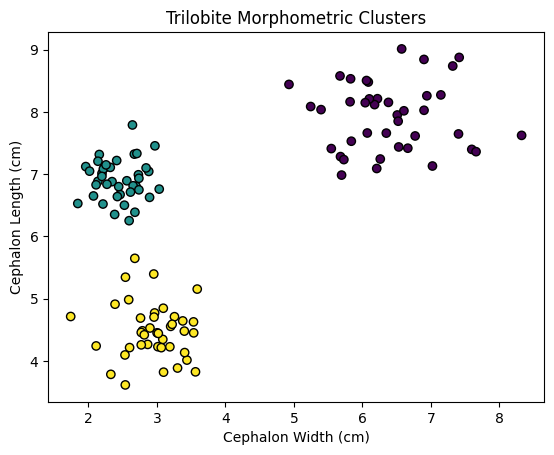

In [7]:
# Synthetic Fossil Dimensions: [Width (cm), Length (cm)]
np.random.seed(12)
species_1 = np.random.normal([3.0, 4.5], 0.4, (40, 2))
species_2 = np.random.normal([6.5, 8.0], 0.6, (40, 2))
species_3 = np.random.normal([2.5, 7.0], 0.3, (40, 2))
fossil_data = np.vstack([species_1, species_2, species_3])

kmeans = KMeans(n_clusters=3 , random_state=42)

labels = kmeans.fit_predict(fossil_data)

plt.scatter(fossil_data[:, 0], fossil_data[:, 1], c=labels, cmap='viridis', edgecolor='k')
plt.xlabel("Cephalon Width (cm)")
plt.ylabel("Cephalon Length (cm)")
plt.title("Trilobite Morphometric Clusters")
plt.show()

**Why is clustering considered "Unsupervised Learning"?**

Because there were no initial species, the machine had to figure it out.

**If you ran this algorithm with n_clusters=2 instead of 3, how would the algorithm decide to group the data?**

It merges the two most similar groups. It would be based on distance.

In [15]:
# Features: [Silica%, Iron%, Magnesium%]
# Labels: 0 = Basalt (Low Silica, High Fe/Mg), 1 = Granite (High Silica, Low Fe/Mg)
X_rocks = np.array([
    [48.2, 11.5, 8.2], [45.1, 13.2, 9.1], [50.3, 10.1, 7.5], [49.5, 12.0, 8.0], # Basalts
    [72.5, 2.1, 0.5], [70.1, 3.5, 1.2], [75.4, 1.8, 0.2], [73.0, 2.5, 0.8]      # Granites
])
y_rocks = np.array([0, 0, 0, 0, 1, 1, 1, 1])

mlp = MLPClassifier(hidden_layer_sizes=(10, 10), max_iter=1000, random_state=42)

mlp.fit(X_rocks, y_rocks)

new_sample = [[46.0, 12.0, 8.5]]
prediction = mlp.predict(new_sample)

rock_type = "Granite" if prediction[0] == 1 else "Basalt"
print(f"The Neural Network classifies the new sample as: {rock_type}")

The Neural Network classifies the new sample as: Basalt


**In an MLP, what does a "hidden layer" do?**

It transforms features by weighing combinations of data allowing the machine to learn complex patterns.

**If a rock had exactly 60% Silica, 7% Iron, and 4% Magnesium, do you think the network would be highly confident or uncertain? Why?**

I feel that the machine would be uncertain because those are the boundary values and it may not have the proper training to deal with the boundaries.

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Training RNN...
Training complete!
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step


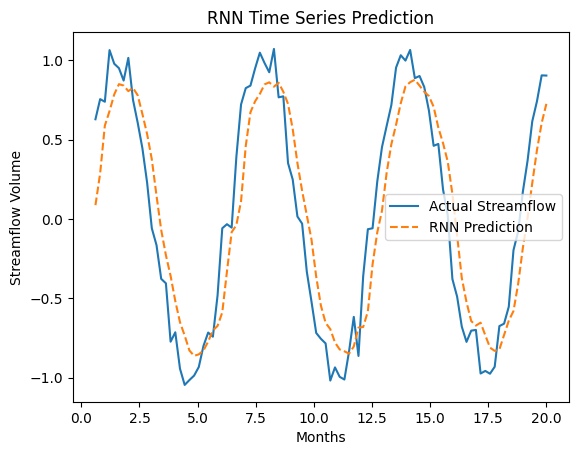

In [16]:
# Synthetic Streamflow Data: A sine wave with added noise (representing seasons)
time_steps = np.linspace(0, 20, 100)
streamflow = np.sin(time_steps) + np.random.normal(0, 0.1, 100)

X_hydro, y_hydro = [], []
for i in range(len(streamflow) - 3):
    X_hydro.append(streamflow[i:i+3])
    y_hydro.append(streamflow[i+3])

X_hydro = np.array(X_hydro).reshape(-1, 3, 1) # Reshape for RNN: (Samples, Time Steps, Features)
y_hydro = np.array(y_hydro)

model_rnn = Sequential()

model_rnn.add(SimpleRNN(units=10, input_shape=(3, 1)))

model_rnn.add(Dense(units=1))

model_rnn.compile(optimizer='adam', loss='mse')

print("Training RNN...")
model_rnn.fit(X_hydro, y_hydro, epochs=20, verbose=0)
print("Training complete!")

predictions = model_rnn.predict(X_hydro)

plt.plot(time_steps[3:], y_hydro, label="Actual Streamflow")
plt.plot(time_steps[3:], predictions, label="RNN Prediction", linestyle='dashed')
plt.xlabel("Months")
plt.ylabel("Streamflow Volume")
plt.legend()
plt.title("RNN Time Series Prediction")
plt.show()

**Why is an RNN better suited for streamflow prediction than a standard MLP or Random Forest?**

RNN has the ability to remember things in a sequence, this gives it the ability to learn on a temporal scale that MLP cannot do.

**If we changed the input sequence from 3 months to 12 months, how might that help the model understand seasonal data?**

It would give the RNN the aiblity to see the full seasonal data and learn more in depth detail on the data. It would even help it recognize periodic trends.